  # Como os senadores usam a cota parlamentar (CEAPS)
  Pergunta central: Como está sendo distribuido os gastos do orçamento de reembolso de cota?
  Dataset: CEAPS (Senado Federal) — reembolsos da cota | Período: 2019 - 2022(série pública: 2008-2022)
  Granularidade: Cada linha é um lançamento de reembolso de cota.

# Verificação dos dados do ano de 2022

In [32]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
url = "https://www.senado.gov.br/transparencia/LAI/verba/despesa_ceaps_2022.csv"
df = pd.read_csv(url, sep=';', encoding='latin-1', skiprows=1, decimal=',')

In [33]:
display(df.info())
display(df.shape)
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16805 entries, 0 to 16804
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   ANO                16805 non-null  int64  
 1   MES                16805 non-null  int64  
 2   SENADOR            16805 non-null  object 
 3   TIPO_DESPESA       16805 non-null  object 
 4   CNPJ_CPF           16805 non-null  object 
 5   FORNECEDOR         16805 non-null  object 
 6   DOCUMENTO          15871 non-null  object 
 7   DATA               16805 non-null  object 
 8   DETALHAMENTO       9062 non-null   object 
 9   VALOR_REEMBOLSADO  16805 non-null  float64
 10  COD_DOCUMENTO      16805 non-null  int64  
dtypes: float64(1), int64(3), object(7)
memory usage: 1.4+ MB


None

(16805, 11)

,ANO,MES,SENADOR,TIPO_DESPESA,CNPJ_CPF,FORNECEDOR,DOCUMENTO,DATA,DETALHAMENTO,VALOR_REEMBOLSADO,COD_DOCUMENTO
0,2022,1,ACIR GURGACZ,"Aluguel de imóveis para escritório político, c...",004.948.028-63,GILBERTO PISELO DO NASCIMENTO,001/22,03/01/2022,Despesa com pagamento de aluguel de imóvel par...,6000.0,2173614
1,2022,1,ACIR GURGACZ,Divulgação da atividade parlamentar,26.320.603/0001-64,INFORMANAHORA,000000000000310/A,04/01/2022,Despesa com divulgação da atividade parlamenta...,1500.0,2173615
2,2022,1,ACIR GURGACZ,Divulgação da atividade parlamentar,13.659.201/0001-47,LINHA PURPURA FOTO E VIDEO LTDA,107,14/01/2022,Despesa com produção de texto e edição de víde...,6000.0,2173616
3,2022,1,ACIR GURGACZ,Divulgação da atividade parlamentar,23.652.846/0001-01,ROBERTO GUTIERREZ DA ROCHA M.E.I.,187,18/01/2022,Divulgação da atividade parlamentar,1000.0,2173618
4,2022,1,ACIR GURGACZ,Divulgação da atividade parlamentar,08.941.827/0001-01,RONDONIA DINÂMICA COM. E SERV. DE INFORMÁTICA ...,000000000001772/A,17/01/2022,Divulgação da atividade parlamentar,2000.0,2173617


Antes de começarmos as analises dos detalhamentos, vamos verificar o valor total gasto.

In [34]:
df['VALOR_REEMBOLSADO'].sum()

np.float64(27323316.33)

As colunas DETALHAMENTO e DOCUMENTO, apresentam valores faltantes.

In [35]:
df['FORNECEDOR'].value_counts().head(20)


,count
FORNECEDOR,
ADRIA VIAGENS E TURISMO LTDA,636
LATAM,415
GOL,245
UBER DO BRASIL TECNOLOGIA LTDA.,230
AZUL,160
Auto Posto Irmãos Miguel LTDA,145
UBER DO BRASILTECNOLOGIA LTDA.,113
LM TURISMO,112
Adria Viagens e Turismo Ltda,112


A Coluna FORNECEDOR possui multiplos valores aparecendo escritas de forma diferente

In [36]:
df.isna().sum().sort_values()

,0
ANO,0
MES,0
SENADOR,0
TIPO_DESPESA,0
CNPJ_CPF,0
FORNECEDOR,0
DATA,0
VALOR_REEMBOLSADO,0
COD_DOCUMENTO,0
DOCUMENTO,934


O data frame conta atualmente com duas colunas com dados faltantes, após analise preliminar foi decidido que as colunas seriam dropadas, motivos, para analise inicial e sem a interpolaçao com outros datasets, o numero do documento não pareceu relevante, e a coluna detalhamento em primeira analise foi considerada redundante com a coluna TIPO_DESPESA de modo que a grande quantidade de dados faltantes presentes nela, não atrapalhem na analise posterior.

In [37]:

df = df.drop(columns=['DOCUMENTO', 'DETALHAMENTO']);
df

,ANO,MES,SENADOR,TIPO_DESPESA,CNPJ_CPF,FORNECEDOR,DATA,VALOR_REEMBOLSADO,COD_DOCUMENTO
0,2022,1,ACIR GURGACZ,"Aluguel de imóveis para escritório político, c...",004.948.028-63,GILBERTO PISELO DO NASCIMENTO,03/01/2022,6000.00,2173614
1,2022,1,ACIR GURGACZ,Divulgação da atividade parlamentar,26.320.603/0001-64,INFORMANAHORA,04/01/2022,1500.00,2173615
2,2022,1,ACIR GURGACZ,Divulgação da atividade parlamentar,13.659.201/0001-47,LINHA PURPURA FOTO E VIDEO LTDA,14/01/2022,6000.00,2173616
3,2022,1,ACIR GURGACZ,Divulgação da atividade parlamentar,23.652.846/0001-01,ROBERTO GUTIERREZ DA ROCHA M.E.I.,18/01/2022,1000.00,2173618
4,2022,1,ACIR GURGACZ,Divulgação da atividade parlamentar,08.941.827/0001-01,RONDONIA DINÂMICA COM. E SERV. DE INFORMÁTICA ...,17/01/2022,2000.00,2173617
...,...,...,...,...,...,...,...,...,...
16800,2022,12,ZEQUINHA MARINHO,"Passagens aéreas, aquáticas e terrestres nacio...",22.052.777/0001-32,Exceller Tour,06/12/2022,2893.04,2191398
16801,2022,12,ZEQUINHA MARINHO,"Passagens aéreas, aquáticas e terrestres nacio...",22.052.777/0001-32,Exceller Tour,09/12/2022,1180.19,2192272
16802,2022,12,ZEQUINHA MARINHO,"Passagens aéreas, aquáticas e terrestres nacio...",22.052.777/0001-32,Exceller Tour,20/12/2022,2671.90,2192274
16803,2022,12,ZEQUINHA MARINHO,"Passagens aéreas, aquáticas e terrestres nacio...",22.052.777/0001-32,Exceller Tour,21/12/2022,1334.31,2192244


In [38]:
df['DATA'] = pd.to_datetime(df['DATA'], dayfirst=True, errors='coerce')
df['DATA'].isna().sum();

Alterando a data, para um padrão de melhor manipulação

In [39]:
df['TIPO_DESPESA'].value_counts()

,count
TIPO_DESPESA,
"Locomoção, hospedagem, alimentação, combustíveis e lubrificantes",6769
"Passagens aéreas, aquáticas e terrestres nacionais",3383
"Aluguel de imóveis para escritório político, compreendendo despesas concernentes a eles.",3322
"Aquisição de material de consumo para uso no escritório político, inclusive aquisição ou locação de software, despesas postais, aquisição de publicações, locação de móveis e de equipamentos.",1226
"Contratação de consultorias, assessorias, pesquisas, trabalhos técnicos e outros serviços de apoio ao exercício do mandato parlamentar",1043
Divulgação da atividade parlamentar,1038
Serviços de Segurança Privada,24


Verificação da existencia de mais catégorias "iguais" porem escritas de maneiras diferentes.

Vamos começar a limpar o campo fornecedor aqui.

In [40]:
df['FORNECEDOR'].value_counts().head(20)

,count
FORNECEDOR,
ADRIA VIAGENS E TURISMO LTDA,636
LATAM,415
GOL,245
UBER DO BRASIL TECNOLOGIA LTDA.,230
AZUL,160
Auto Posto Irmãos Miguel LTDA,145
UBER DO BRASILTECNOLOGIA LTDA.,113
LM TURISMO,112
Adria Viagens e Turismo Ltda,112


In [41]:
mapper = {
    'UBER' : 'UBER DO BRASIL TECNOLOGIA LTDA.',
    'ÁDRI' : 'ADRIA VIAGENS E TURISMO LTDA',
    'ADRI' : 'ADRIA VIAGENS E TURISMO LTDA'
}
for prefixo, nome_padrao in mapper.items():
    mask = df['FORNECEDOR'].str.upper().str.startswith(prefixo.upper(), na=False)
    df.loc[mask, 'FORNECEDOR'] = nome_padrao


Foi identificado os maiores fornecedores que mais se repetiam, e normalizados para um nome em comum.

In [42]:
gasto = df.groupby('SENADOR').agg(valor_gasto=('VALOR_REEMBOLSADO', 'sum')).sort_values('valor_gasto', ascending=False)
qtd_mes = df.groupby('SENADOR')['MES'].nunique()
media_mes = pd.merge(gasto, qtd_mes, on='SENADOR', how='inner')
media_mes['Media_mensal'] = media_mes['valor_gasto'] / media_mes['MES']
media_mes.sort_values('Media_mensal', ascending=False).head(10)

,valor_gasto,MES,Media_mensal
SENADOR,,,
LUCAS BARRETO,511319.78,12,42609.981667
DAVI ALCOLUMBRE,505054.54,12,42087.878333
OMAR AZIZ,494369.33,12,41197.444167
TELMÁRIO MOTA,488693.40,12,40724.450000
MECIAS DE JESUS,488586.66,12,40715.555000
ROGÉRIO CARVALHO,487764.65,12,40647.054167
RANDOLFE RODRIGUES,487758.92,12,40646.576667
CHICO RODRIGUES,486958.05,12,40579.837500
MAILZA GOMES,465899.61,12,38824.967500


Aqui identificamos os 10 Senadores com o maior média de gasto mensal. E identificamos também que neste ano todos tiveram mandato completo(12meses)

In [43]:
gasto_despesa = df.groupby('TIPO_DESPESA').agg(total_gasto=('VALOR_REEMBOLSADO', 'sum'), qtd_senadores=('SENADOR','nunique'))
gasto_despesa['percent_doTotal'] = gasto_despesa['total_gasto'] / df['VALOR_REEMBOLSADO'].sum()
gasto_despesa

,total_gasto,qtd_senadores,percent_doTotal
TIPO_DESPESA,,,
"Aluguel de imóveis para escritório político, compreendendo despesas concernentes a eles.",3976536.92,82,0.145536
"Aquisição de material de consumo para uso no escritório político, inclusive aquisição ou locação de software, despesas postais, aquisição de publicações, locação de móveis e de equipamentos.",983707.82,56,0.036003
"Contratação de consultorias, assessorias, pesquisas, trabalhos técnicos e outros serviços de apoio ao exercício do mandato parlamentar",6321484.03,79,0.231359
Divulgação da atividade parlamentar,3345915.36,55,0.122456
"Locomoção, hospedagem, alimentação, combustíveis e lubrificantes",5259803.51,82,0.192502
"Passagens aéreas, aquáticas e terrestres nacionais",7423646.13,90,0.271696
Serviços de Segurança Privada,12222.56,5,0.000447


Verificando para quais tipos de despesa o valor é utilizado, e quantos senadores utilizaram a despesa.

In [44]:
valor_fornecedor = df.groupby('FORNECEDOR').agg(valor_recebido=('VALOR_REEMBOLSADO', 'sum'), qtd_contratos=('COD_DOCUMENTO', 'count')).sort_values('valor_recebido', ascending=False)
valor_fornecedor['perc_total'] = valor_fornecedor['valor_recebido'] / df['VALOR_REEMBOLSADO'].sum()
valor_fornecedor.head(10)

,valor_recebido,qtd_contratos,perc_total
FORNECEDOR,,,
ADRIA VIAGENS E TURISMO LTDA,2424390.47,1224,0.088730
LATAM,886836.74,415,0.032457
GOL,538930.03,245,0.019724
UPLINK Assessoria e Consultoria Empresarial Eireli -ME,360000.00,12,0.013176
LEONARDO CRUZ SOCIEDADE INDIVIDUAL DE ADVOCACIA,343000.00,9,0.012553
AZUL,300849.41,160,0.011011
L COELHO SERRA,300000.00,12,0.010980
BORA COMUNICAÇÃO E MARKETING DIGITAL LTDA,300000.00,12,0.010980
LM TURISMO,284495.51,112,0.010412


Top 10 fornecedores que mais receberam valores.

### Sazonalidade (2022)
Gasto mês a mês em 2022. Se o padrão se repete ano a ano fica como próximo passo, sobre 2019-2022.

,VALOR_REEMBOLSADO
MES,
1,1.814947
2,2.251777
3,2.735146
4,2.416977
5,2.573132
6,2.223460
7,2.201190
8,2.107864
9,1.637101


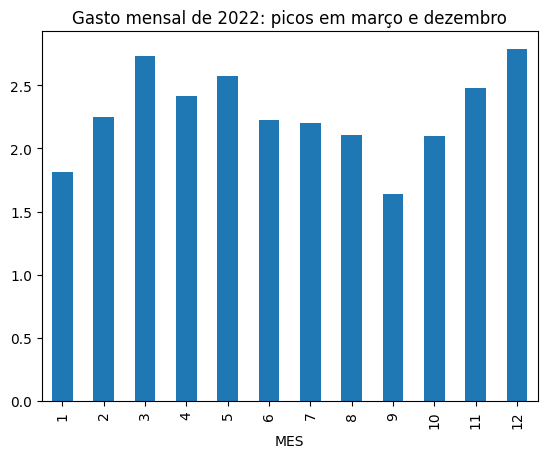

In [65]:
sazonalidade = (df.groupby('MES')['VALOR_REEMBOLSADO'].sum() / 1e6)
sazonalidade.plot(kind='bar',title='Gasto mensal de 2022: picos em março e dezembro')
sazonalidade

 Os picos encontrados no mês 3 e 12, podem sugerir maiores gastos em meses de ferias e festas como carnaval, pode ser explicado se o gasto tiver sido utilizado majoritariamente em passagens aereas

<Axes: xlabel='MES'>

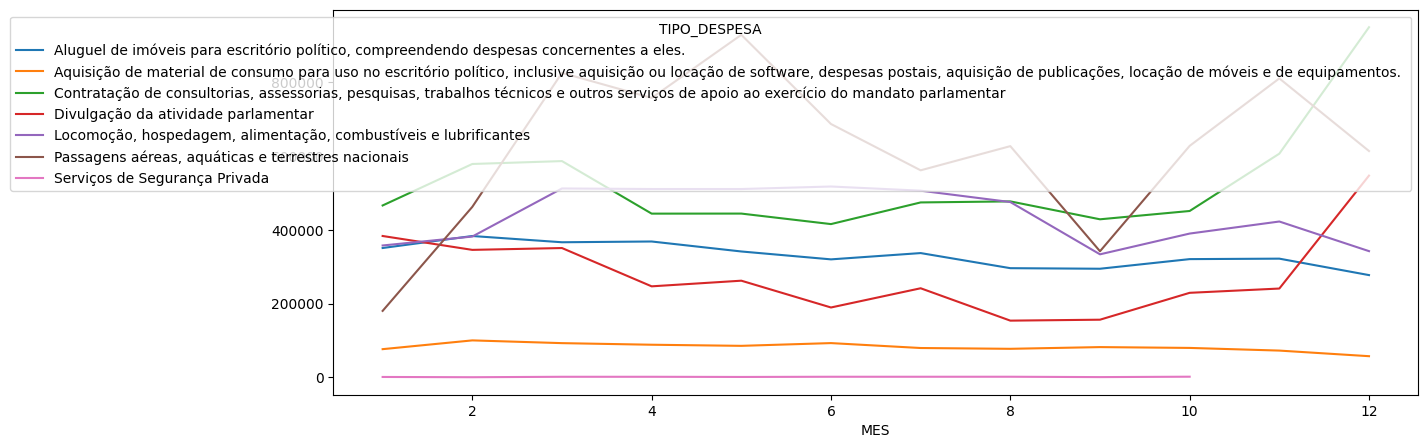

In [49]:
saz_tipo = df.pivot_table(index='MES', columns='TIPO_DESPESA', values='VALOR_REEMBOLSADO', aggfunc='sum')
saz_tipo.plot(kind='line', figsize=[14,5])

 A hipotese anterior cai, pela verificação feita na distribuição pelo tipo de despesa, a partir dela podemos verificar o exponencial crescimento de contratação de consulturias nestes dois meses, e no mês 12 um crescimento muito significativo na divulgação de atividade parlamentar, falta a verificação se isso é um acontecimento recorrente ano a ano, ou se neste especifico pode ter acontecido algo que gerou esta necessidade ou oportunidade.

Em 2022 as passagens dominam o gasto. Resta ver como isso se comporta nos outros anos — é o que a próxima seção investiga, sobre 2019-2022.

# Anos 2019 - 2022
### A partir deste momento começaremos a analisar multiplos anos de referencia para entender como as questões anteriores se comportam em um periodo temporal maior.

In [45]:
anos = [2019, 2020, 2021, 2022]
base_url = "https://www.senado.gov.br/transparencia/LAI/verba/despesa_ceaps_{ano}.csv"

dfs = []
for ano in anos:
    d = pd.read_csv(base_url.format(ano=ano), sep=';', encoding='latin-1', skiprows=1, decimal=',')
    dfs.append(d)

df_full = pd.concat(dfs, axis=0, ignore_index=True)
print(df_full.shape)

(69356, 11)


Vamos fazer as mesmas limpezas e alterações que foram feitos anteriormente para manter a isonomia, dos dados.



In [46]:

ceaps = df_full.drop(columns=['DOCUMENTO', 'DETALHAMENTO']);
ceaps['DATA'] = pd.to_datetime(ceaps['DATA'], dayfirst=True, errors='coerce')
mapper = {
    'UBER' : 'UBER DO BRASIL TECNOLOGIA LTDA.',
    'ÁDRI' : 'ADRIA VIAGENS E TURISMO LTDA',
    'ADRI' : 'ADRIA VIAGENS E TURISMO LTDA'
}
for prefixo, nome_padrao in mapper.items():
    mask = ceaps['FORNECEDOR'].str.upper().str.startswith(prefixo.upper(), na=False)
    ceaps.loc[mask, 'FORNECEDOR'] = nome_padrao

ceaps.head()

,ANO,MES,SENADOR,TIPO_DESPESA,CNPJ_CPF,FORNECEDOR,DATA,VALOR_REEMBOLSADO,COD_DOCUMENTO
0,2019,1,ACIR GURGACZ,"Aluguel de imóveis para escritório político, c...",05.914.650/0001-66,ENERGISA,2019-01-04,66.02,2116543
1,2019,1,ACIR GURGACZ,"Aluguel de imóveis para escritório político, c...",05.914.650/0001-66,ENERGISA,2019-01-04,139.98,2116546
2,2019,1,ACIR GURGACZ,"Aluguel de imóveis para escritório político, c...",004.948.028-63,GILBERTO PISELO DO NASCIMENTO,2019-01-07,6000.00,2113817
3,2019,1,ACIR GURGACZ,"Aluguel de imóveis para escritório político, c...",05.423.963/0001-11,OI MÓVEL S.A.,2018-12-25,316.39,2116541
4,2019,2,ACIR GURGACZ,"Aluguel de imóveis para escritório político, c...",05.914.650/0001-66,ENERGISA,2019-02-04,99.45,2116550


Verificação de Sazonalidade.

<Axes: title={'center': 'Reembolso total cai em 2020 e volta a subir nos anos sequentes'}, xlabel='ANO'>

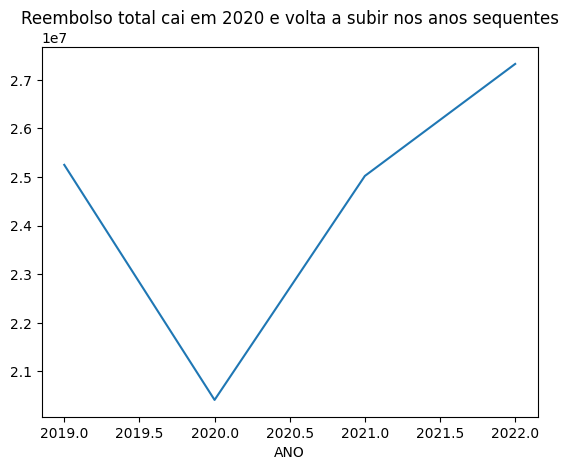

In [64]:
ceaps.groupby("ANO")["VALOR_REEMBOLSADO"].sum().plot(kind='line', title='Reembolso total cai em 2020 e volta a subir nos anos sequentes')

Verificamos a diferença de valores de reembolsos ano a ano

<Axes: title={'center': 'Lançamentos caem 35% em 2020 (21,6k → 14,1k)'}, xlabel='ANO'>

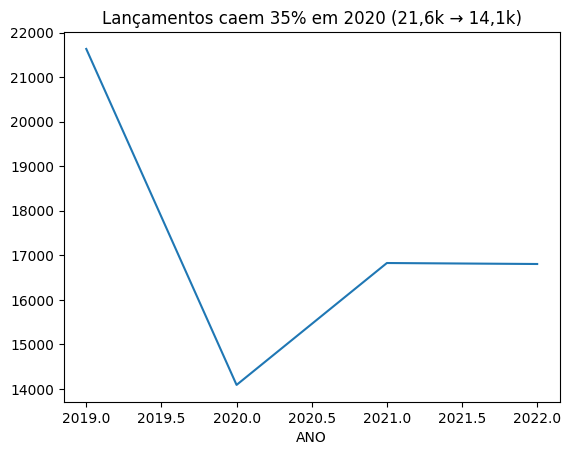

In [66]:
ceaps.groupby("ANO").size().plot(kind='line', title='Lançamentos caem 35% em 2020 (21,6k → 14,1k)')

Podemos verificar que nos anos de pandemia, o valor de Reembolsos diminuiu, embora o a quantidade dos mesmos tenha reduzido em uma proporção similar, podemos inferir que os valores não diminuiram, e sim a quantidades de solicitações feitas

In [52]:
ceaps.pivot_table(index="ANO", columns='TIPO_DESPESA',values="VALOR_REEMBOLSADO", aggfunc='sum')

TIPO_DESPESA,"Aluguel de imóveis para escritório político, compreendendo despesas concernentes a eles.","Aquisição de material de consumo para uso no escritório político, inclusive aquisição ou locação de software, despesas postais, aquisição de publicações, locação de móveis e de equipamentos.","Contratação de consultorias, assessorias, pesquisas, trabalhos técnicos e outros serviços de apoio ao exercício do mandato parlamentar",Divulgação da atividade parlamentar,"Locomoção, hospedagem, alimentação, combustíveis e lubrificantes","Passagens aéreas, aquáticas e terrestres nacionais",Serviços de Segurança Privada
ANO,,,,,,,
2019,4175159.47,871498.33,5931522.01,2344364.06,4451860.48,7431967.46,41870.59
2020,3933698.86,899557.98,6126389.76,3189665.10,3589103.72,2636436.20,40071.98
2021,4054218.19,1019921.16,6001073.98,4039199.48,4481746.07,5380211.87,43953.09
2022,3976536.92,983707.82,6321484.03,3345915.36,5259803.51,7423646.13,12222.56


In [53]:
pd.crosstab(
    index=ceaps['ANO'],
    columns=ceaps['TIPO_DESPESA'],
    values=ceaps['VALOR_REEMBOLSADO'],
    aggfunc='sum',
    normalize='index'
)

TIPO_DESPESA,"Aluguel de imóveis para escritório político, compreendendo despesas concernentes a eles.","Aquisição de material de consumo para uso no escritório político, inclusive aquisição ou locação de software, despesas postais, aquisição de publicações, locação de móveis e de equipamentos.","Contratação de consultorias, assessorias, pesquisas, trabalhos técnicos e outros serviços de apoio ao exercício do mandato parlamentar",Divulgação da atividade parlamentar,"Locomoção, hospedagem, alimentação, combustíveis e lubrificantes","Passagens aéreas, aquáticas e terrestres nacionais",Serviços de Segurança Privada
ANO,,,,,,,
2019,0.165364,0.034517,0.234928,0.092853,0.176324,0.294356,0.001658
2020,0.192687,0.044064,0.300094,0.156242,0.175808,0.129143,0.001963
2021,0.162037,0.040764,0.239848,0.161437,0.179124,0.215034,0.001757
2022,0.145536,0.036003,0.231359,0.122456,0.192502,0.271696,0.000447


Verificamos aqui a quantidade e a porcentagem em cima do valor total, representada dos tipos de gastos ano a ano

In [54]:
ceaps['ANO_MES_UTILIZADO'] = pd.to_datetime(ceaps['DATA']).dt.to_period('M')
gasto_mensal = ceaps.groupby('ANO_MES_UTILIZADO', as_index=False)['VALOR_REEMBOLSADO'].sum().sort_values('ANO_MES_UTILIZADO')
gasto_mensal

,ANO_MES_UTILIZADO,VALOR_REEMBOLSADO
0,2000-12,1070.92
1,2002-02,6033.16
2,2002-03,25653.23
3,2002-06,1605.00
4,2002-08,1032.69
...,...,...
71,2023-01,218416.17
72,2023-02,85247.98
73,2023-03,28000.00
74,2023-11,116.00


A partir deste agrupamento identificamos que aparentemente é possivel solicitar reembolso de gastos em datas muito anteriores, como no caso do anos 2000 e 2002. E levanta a consideração de como efetivamente funciona a solicitação de reembolso. Necessaria maior analise futura.

<Axes: title={'center': 'Valor Reembolsado por Mês-Ano, em Milhões'}, xlabel='ANO_MES'>

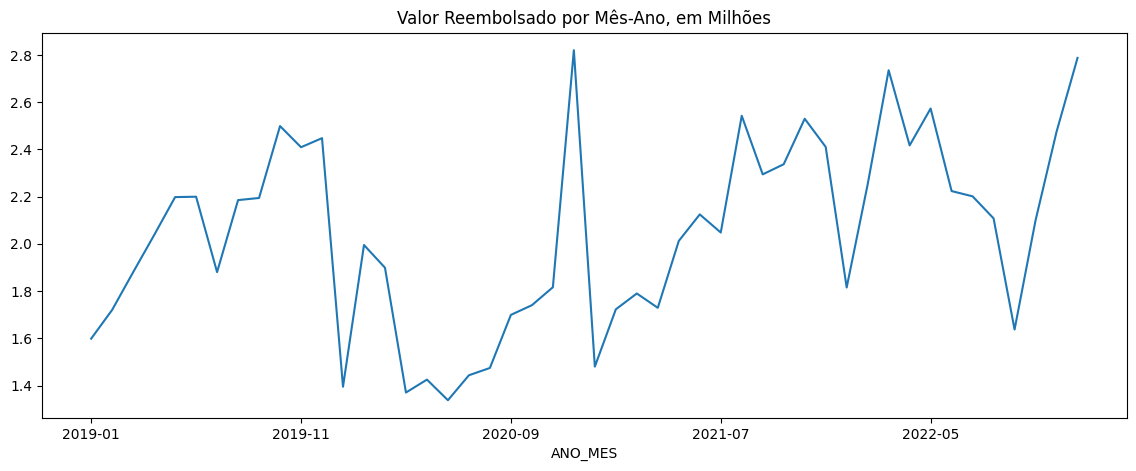

In [69]:

ceaps['ANO_MES'] = ceaps['ANO'].astype(str) + '-' + ceaps['MES'].astype(str).str.zfill(2)
(ceaps.groupby('ANO_MES')['VALOR_REEMBOLSADO'].sum() / 1e6).plot(kind='line', title='Valor Reembolsado por Mês-Ano, em Milhões', figsize=[14,5])

Decisão por considerar os dados com até 2(dois) anos da data de pagamento, como valores de restos a pagar e separar como o ano atual, e dados com data faltantes como anteriores a 2(anos) para identificar se estão acontecendo muitos pagamentos desviantes.

<Axes: title={'center': 'Diferença de Gastos com Data Superior a 2 anos'}, xlabel='ANO_MES'>

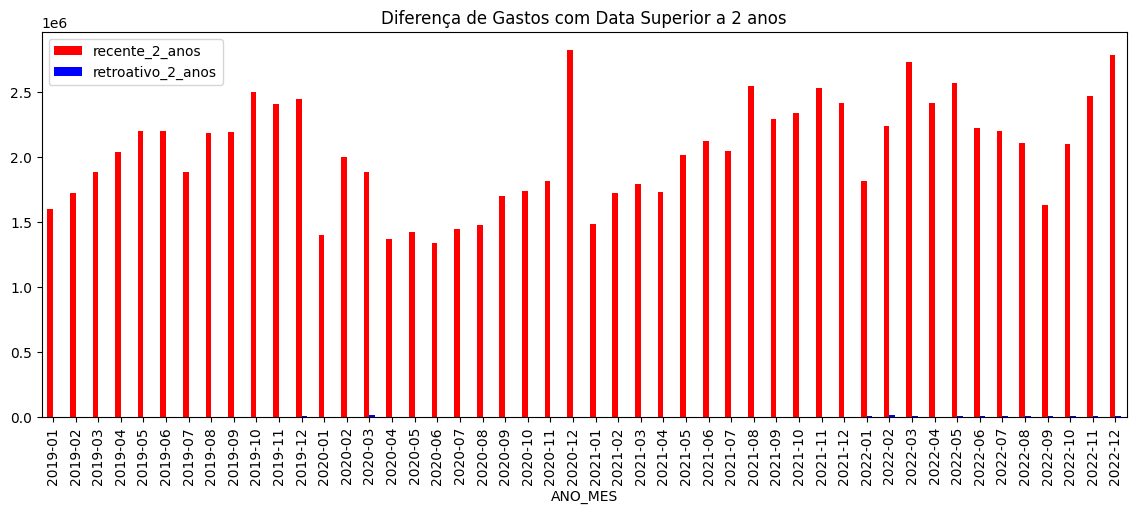

In [62]:
diff_anos = ceaps['ANO'] - ceaps['ANO_MES_UTILIZADO'].dt.year

retroativo = ceaps[(diff_anos > 2) | diff_anos.isna()]
recente    = ceaps[diff_anos <= 2]

soma_retroativo = retroativo.groupby('ANO_MES')['VALOR_REEMBOLSADO'].sum()
soma_recente = recente.groupby('ANO_MES')['VALOR_REEMBOLSADO'].sum()

resultado = pd.DataFrame({
    'recente_2_anos': soma_recente,
    'retroativo_2_anos': soma_retroativo
})

resultado.plot(kind='bar',figsize=(14, 5), color=['red', 'blue'], title='Diferença de Gastos com Data Superior a 2 anos')

<Axes: title={'center': 'Gastos Retroativos a 2 anos'}, xlabel='ANO_MES'>

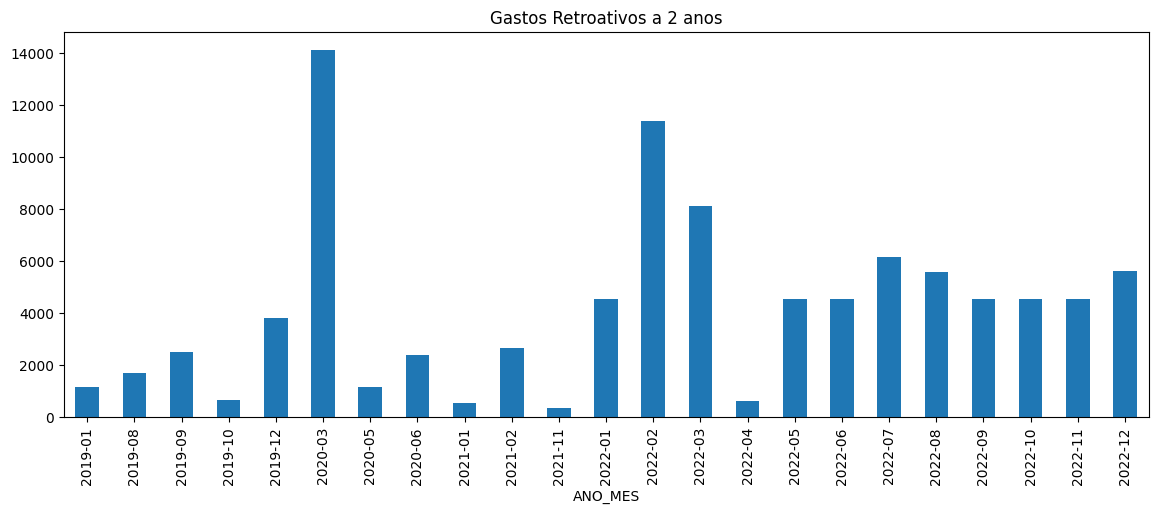

In [60]:
soma_retroativo.plot(kind='bar',figsize=(14, 5), title='Gastos Retroativos a 2 anos')

## Conclusão

A cota parlamentar é, na prática, um orçamento de deslocamento. Em 2022, viagem
(passagens aéreas 27% + locomoção/hospedagem 19%) responde por ~46% dos R\$ 27,3 mi
reembolsados, e uma única agência (Adria Viagens) concentra R\$ 2,4 mi — 8,9% de todo
o reembolso do ano — em 1.224 lançamentos.

O choque de 2020 confirma a leitura: com a pandemia travando viagens, o número de
lançamentos caiu 35% (21,6 mil → 14,1 mil) e a composição migrou para custos fixos.
A fatia do aluguel subiu de 16% para 19% e a de consultorias de 23% para 30% — não
porque gastaram mais nelas, mas porque o total encolheu.

No recorte por senador, normalizei por mês ativo em vez de total bruto (comparar
totais entre mandatos de durações diferentes mente). O topo de gasto é homogêneo:
os 10 maiores ficam entre R\$ 38,8 mil e R\$ 42,6 mil por mês ativo, todos com
atividade nos 12 meses de 2022.

Por fim, os documentos reembolsados carregam datas de 2000 a 2023 — muito fora dos
anos de exercício (2019-2022). Isso aponta para reembolso retroativo, restos a pagar
ou erro de lançamento, e pede investigação.

### Cinco achados
1. **Viagem domina.** Passagens (27%) + locomoção (19%) = ~46% dos R\$ 27,3 mi em 2022.
2. **Concentração em fornecedor de viagem.** Adria Viagens: 8,9% de todo o reembolso,
   1.224 lançamentos. Com LATAM e GOL, o setor aéreo lidera de longe.
3. **2020 quebrou o padrão, mas só na viagem.** Lançamentos -35%; aluguel e consultoria
   ganharam participação porque o denominador caiu.
4. **Topo de gasto parelho.** R\$ 38,8k a R\$ 42,6k por mês ativo entre os 10 maiores.
5. **Datas fora do exercício.** Documentos de 2000 a 2023 expõem inconsistência de
   data — o tipo de problema que se aprende a caçar mexendo com dado financeiro.

### Próximos passos
Estatística descritiva (média vs mediana do gasto por lançamento, percentis),
um teste de hipótese entre tipos de despesa e a checagem multi-anos da sazonalidade.